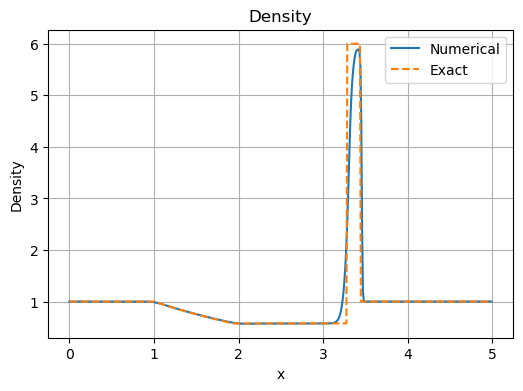

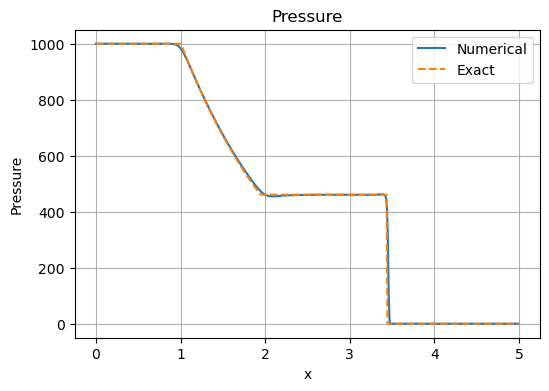

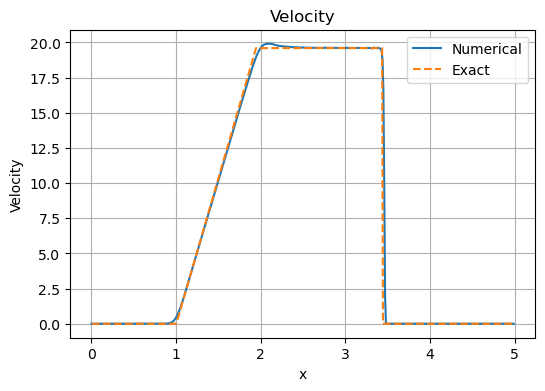

In [5]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
import rusanov_euler_eq_solver as r

gamma = 1.4
dt = 0.00001
N = 500
dx = 0.01
x = np.arange(N) * dx
t = 0.0
t_end = 0.04

solver = r.Rusanov_Euler_Eq_Solver(dt=dt, dx=dx, gamma=gamma)

# Conserved variables: density, momentum, and total energy.
U = np.zeros((N, 3))

# Initial conditions for Toro's Test 3:
# a large pressure difference across the discontinuity at x = 2.5.
for i in range(N):

    if x[i] <= 2.5:
        rho = 1.0
        v = 0.0
        p = 1000
    else:
        rho = 1.0
        v = 0.0
        p = 0.01

    momentum = rho * v

    # Total energy density from pressure and kinetic energy.
    E = p / (gamma - 1) + 0.5 * rho * v**2

    U[i] = [rho, momentum, E]

# Evolve the solution until the final time.
while t < t_end:
    U = solver.time_step(U)
    t += dt

# Convert the conserved variables back to physical variables.
rho = U[:, 0]
momentum = U[:, 1]
E = U[:, 2]

v = momentum / rho
p = (gamma - 1) * (E - momentum**2 / (2 * rho))

# Load the exact solution for comparison.
exact = np.loadtxt(ROOT / "data" / "toro_3_exact.dat", skiprows=9)
x_exact = exact[:, 0]
rho_exact = exact[:, 1]
p_exact = exact[:, 2]
v_exact = exact[:, 3]

# Density
plt.figure(figsize=(6, 4))
plt.plot(x, rho, label="Numerical")
plt.plot(x_exact, rho_exact, "--", label="Exact")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Density")
plt.grid()
plt.legend()
plt.show()

# Pressure
plt.figure(figsize=(6, 4))
plt.plot(x, p, label="Numerical")
plt.plot(x_exact, p_exact, "--", label="Exact")
plt.xlabel("x")
plt.ylabel("Pressure")
plt.title("Pressure")
plt.grid()
plt.legend()
plt.show()

# Velocity
plt.figure(figsize=(6, 4))
plt.plot(x, v, label="Numerical")
plt.plot(x_exact, v_exact, "--", label="Exact")
plt.xlabel("x")
plt.ylabel("Velocity")
plt.title("Velocity")
plt.grid()
plt.legend()
plt.show()

